# Cartographie des sous-cultures : Analyse comparative Incels vs Femcels

> **Objectif de recherche :** Ces deux communautés sont souvent traitées comme des miroirs genrés l'un de l'autre. Mais le sont-elles vraiment ? Ce notebook mobilise les outils differents pour tester trois hypothèses :
>
> **H1 Convergence linguistique :** Malgré le genre opposé, incels et femcels partagent un vocabulaire et des thématiques suffisamment similaires pour qu'un classifieur automatique peine à les distinguer.
>
> **H2  Asymétrie émotionnelle :** La tonalité émotionnelle diffère en nature : l'une des communautés serait davantage orientée vers la colère, l'autre vers la tristesse.
>
> **H3 Chambre d'écho :** La concentration du discours autour d'un petit nombre d'auteurs, combinée à un appauvrissement du vocabulaire dans le temps, indique un effet de chambre d'écho.

---

**Techniques mobilisées :**
- Prétraitement NLP : `word_tokenize`, stopwords, `WordNetLemmatizer`
- Représentation numérique : `CountVectorizer` (BoW), `TfidfVectorizer`
- Classification de texte : `TfidfVectorizer` + `LogisticRegression` (pipeline sklearn)
- Analyse de sentiment : VADER
- Visualisation : `seaborn`, `matplotlib` (heatmaps, barres, scatter, KDE, boxplot)
- Manipulation de données : `pandas` (groupby, resample, value_counts, .dt)

---

**Plan du notebook :**
1. Configuration et chargement
2. Prétraitement (NLP pipeline)
3. Test de H1 — Un classifieur peut-il distinguer les deux communautés ?
4. Paysage textuel — Vocabulaire partagé vs distinctif (BoW + TF-IDF)
5. Test de H2 — Analyse de sentiment comparative
6. Test de H3 — Concentration et chambre d'écho
7. Cartographie temporelle


---
## Section 1 — Configuration et chargement

Cette section configure l'environnement de recherche en définissant les sources de données, les paramètres de modélisation thématique et la charte graphique de l'analyse.

In [ ]:
# IMPORTS
# pip install pandas matplotlib seaborn nltk scikit-learn vaderSentiment

import re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

for r in ['stopwords', 'wordnet', 'omw-1.4', 'punkt', 'punkt_tab']:
    nltk.download(r, quiet=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

PALETTE = {"incels": "#d62728", "femcels": "#9467bd"}
print('Imports OK.')

Imports OK.


In [ ]:
# CONFIGURATION


INCEL_PATH = "Incels.csv"
FEMCEL_PATH = "Truefemcels.csv"
N_FREQ_WORDS = 20
RANDOM_STATE = 42

In [ ]:
# CHARGEMENT DES DONNÉES

def load_dataset(path: str, name: str):
    df = pd.read_csv(path, engine='python', on_bad_lines='skip')
    df.columns = df.columns.str.strip().str.lower()
    print(f"[{name}] Colonnes : {df.columns.tolist()}")

    if 'text' in df.columns and 'body' not in df.columns:
        df.rename(columns={'text': 'body'}, inplace=True)
    if 'date' in df.columns and 'created_utc' not in df.columns:
        df.rename(columns={'date': 'created_utc'}, inplace=True)

    if 'created_utc' in df.columns:
        col = df['created_utc']
        if pd.api.types.is_numeric_dtype(col):
            df['created_utc'] = pd.to_datetime(col, unit='s', utc=True)
        else:
            df['created_utc'] = pd.to_datetime(col, utc=True, errors='coerce')

    df = df[df['body'].notna()]
    df = df[~df['body'].str.strip().isin(['[deleted]', '[removed]', ''])]
    df['community'] = name
    print(f'[{name}]  {len(df):,} posts  |  {df["author"].nunique():,} auteurs uniques')
    return df

INCEL_PATH = "Incels.csv"
FEMCEL_PATH = "Truefemcels.csv"



---
## Section 2 — Prétraitement du texte

Le prétraitement des textes comprend plusieurs étapes de nettoyage afin de rendre les corpus plus homogènes et exploitables pour l’analyse NLP.

Le pipeline applique :

- la conversion de tous les textes en minuscules ;
- la suppression des URLs, des références Reddit, de la ponctuation et des
chiffres ;
- la suppression des stopwords anglais ainsi que de certains termes parasites liés à la plateforme Reddit ;
- la lemmatisation des mots à l’aide de WordNetLemmatizer afin de regrouper différentes formes d’un même terme.




In [ ]:

# PRÉTRAITEMENT (méthodologie du cours, notebook 9)


# --- FIX: Load dataframes before using them ---
df_incels = load_dataset("/var/Incels.csv", 'incels')
df_femcels = load_dataset("/var/Truefemcels.csv", name='femcels')
datasets = {'incels': df_incels, 'femcels': df_femcels}
# ------------------------------------------------

PLATFORM_NOISE = {
    'like','just','people','get','one','would','also','think','even',
    'really','know','say','make','good','thing','much','still','reddit',
    'post','comment','deleted','removed','amp','gt','http','www','im',
    'dont','cant','ive','youre','thats','theyre','its','got','going',
}

_lemmatizer = WordNetLemmatizer()
_stop_words = set(stopwords.words('english')) | PLATFORM_NOISE

def preprocess(text: str) -> list:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'u/\w+|r/\w+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text, language='english')
    tokens = [_lemmatizer.lemmatize(t) for t in tokens if t not in _stop_words and len(t) > 2]
    return tokens

# Corpus nettoyé (chaîne de tokens joints)
df_incels['clean']  = df_incels['body'].apply(lambda x: ' '.join(preprocess(x)))
df_femcels['clean'] = df_femcels['body'].apply(lambda x: ' '.join(preprocess(x)))

corpus_incels  = df_incels['clean']
corpus_femcels = df_femcels['clean']

print('Exemple (incels) :', corpus_incels.iloc[0][:120], '...')

[incels] Colonnes : ['author', 'date', 'text']
[incels]  929,079 posts  |  37,597 auteurs uniques
[femcels] Colonnes : ['author', 'date', 'text']
[femcels]  258 posts  |  92 auteurs uniques
Exemple (incels) : blogger tarnishedsophia question thatincelblogger ...


Ainsi, après l’extraction et le traitement des données, on observe immédiatement un déséquilibre important entre les deux corpus : la base incel contient plus de 929 000 posts, contre seulement 258 pour les femcels. Cette différence limite la portée comparative de l’analyse et impose une certaine prudence dans l’interprétation des résultats, notamment pour les tendances observées chez les femcels.

---
## Section 3 — Test de H1 : Un classifieur peut-il distinguer les deux communautés ?

**Idée :** si les communautés incels et femcels fonctionnent réellement comme des « miroirs genrés » partageant un univers discursif similaire, alors un modèle automatique devrait avoir des difficultés à distinguer leurs publications.

Pour tester cette hypothèse, nous avons entraîné un pipeline TfidfVectorizer + LogisticRegression, chargé de prédire à quelle communauté appartient chaque post.

Une accuracy élevée signifie que les deux communautés utilisent des vocabulaires et des structures discursives suffisamment **différents** pour être séparés automatiquement - H1 rejetée
Une accuracy proche de 50 % aurait au contraire indiqué **une forte similarité** linguistique - H1 confirmée

Les coefficients du modèle permettent également d’identifier les mots les plus discriminants, c’est-à-dire les termes les plus caractéristiques de chaque communauté.

=== Rapport de classification ===
              precision    recall  f1-score   support

     femcels       0.00      0.00      0.00        65
      incels       1.00      1.00      1.00    232270

    accuracy                           1.00    232335
   macro avg       0.50      0.50      0.50    232335
weighted avg       1.00      1.00      1.00    232335


→ Accuracy = 100.0%


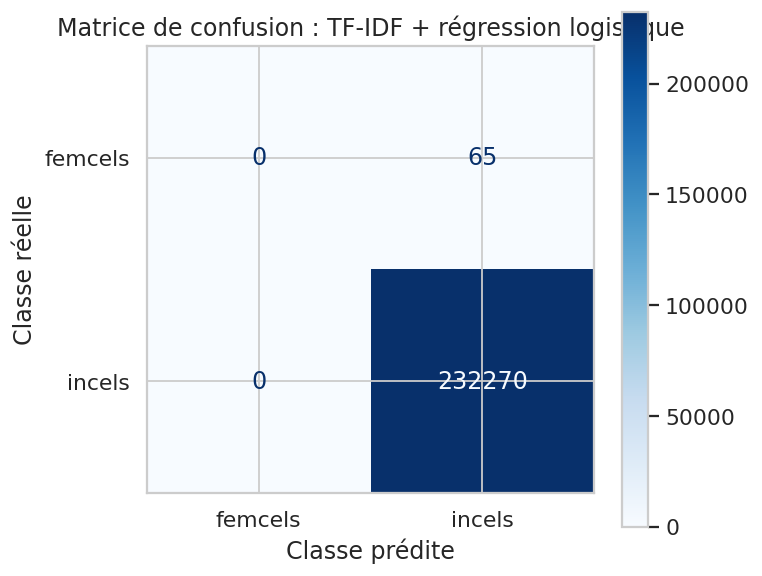

→ Les communautés sont linguistiquement DISTINCTES (H1 rejetée)


In [ ]:

# 3.1 — CLASSIFICATION : TF-IDF + LOGISTIC REGRESSION


# Préparer les données
X = pd.concat([corpus_incels, corpus_femcels])
y = pd.concat([
    pd.Series(['incels'] * len(corpus_incels)),
    pd.Series(['femcels'] * len(corpus_femcels))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Pipeline du cours (notebook 9 : TF-IDF + LogisticRegression)
clf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, max_df=0.9, min_df=5)),
    ('classifieur', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("=== Rapport de classification ===")
print(classification_report(y_test, y_pred))

accuracy = (y_pred == y_test).mean()
print(f"\n→ Accuracy = {accuracy:.1%}")

#Visualisation des données
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Matrice de confusion : TF-IDF + régression logistique")
ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")

plt.tight_layout()
plt.show()
if accuracy > 0.75:
    print("→ Les communautés sont linguistiquement DISTINCTES (H1 rejetée)")
elif accuracy > 0.60:
    print("→ Distinction partielle — chevauchement significatif")
else:
    print("→ Le modèle ne parvient pas à les séparer — H1 confirmée")

Il faut néanmoins nuancer ce résultat:


 l’accuracy très élevée s’explique en partie par le fort déséquilibre entre les deux corpus. Les données incels sont massivement surreprésentées par rapport aux femcels, ce qui pousse le modèle à prédire majoritairement la classe incel. Les performances doivent donc être interprétées avec prudence, notamment pour la classe femcel, beaucoup moins représentée.

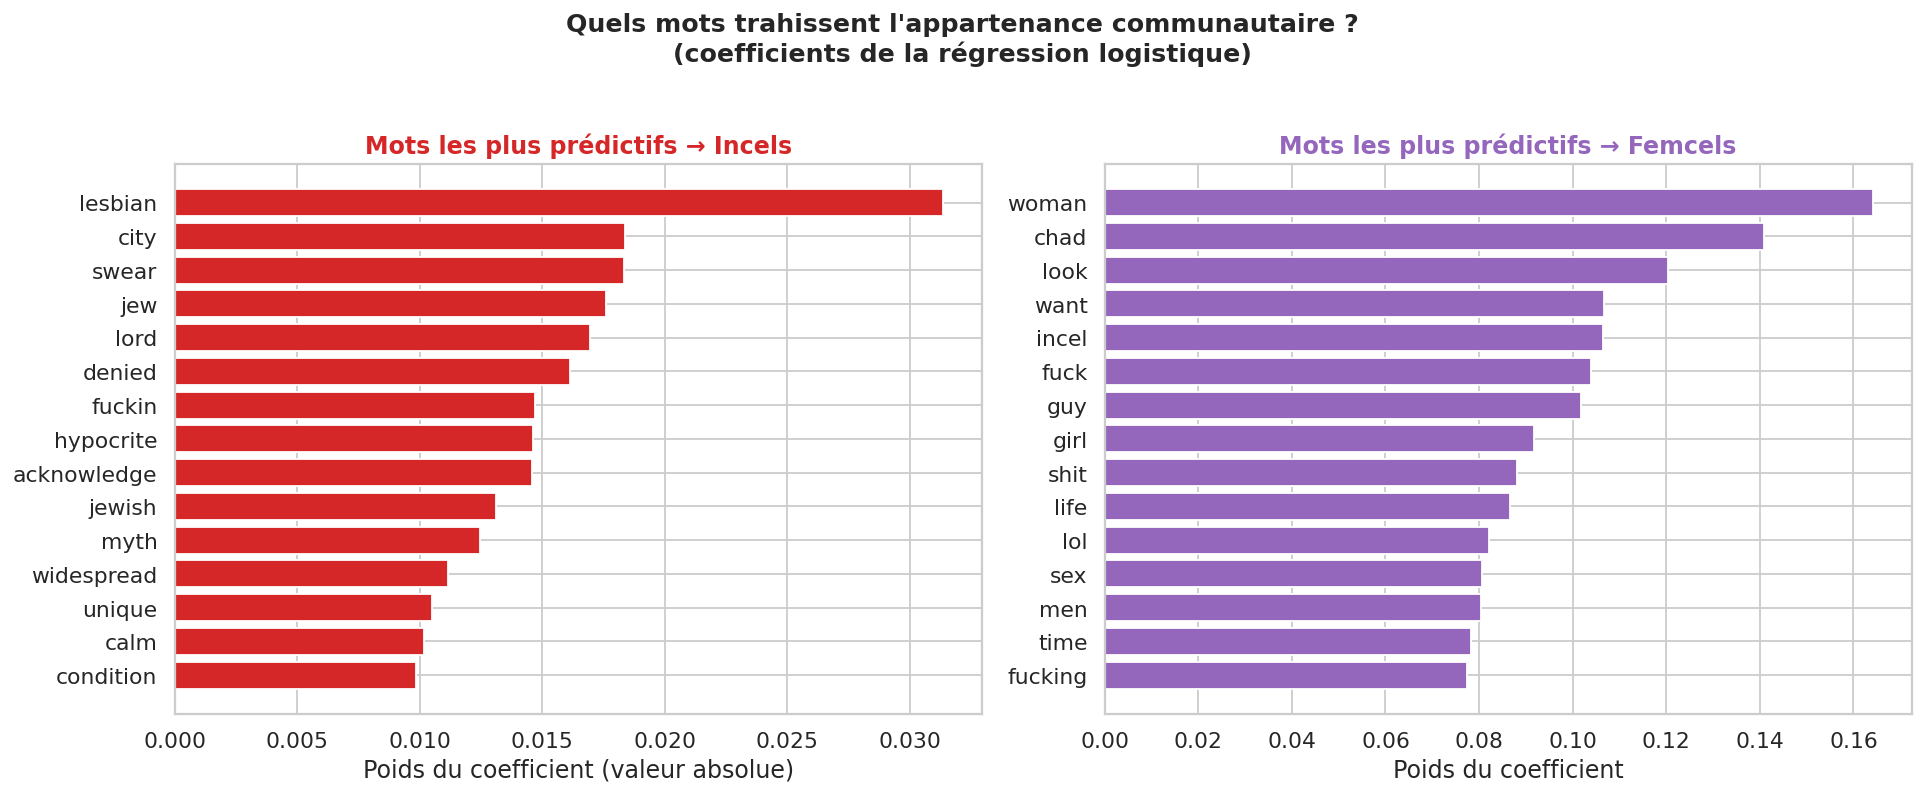

In [ ]:

# 3.2 — MOTS LES PLUS DISCRIMINANTS (coefficients du modèle)

feature_names = clf.named_steps['tfidf'].get_feature_names_out()
coefs = clf.named_steps['classifieur'].coef_[0]

# Coefficients positifs → femcels, négatifs → incels
top_n = 15
top_incels_idx  = coefs.argsort()[:top_n]
top_femcels_idx = coefs.argsort()[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Incels side
words_i = [feature_names[i] for i in top_incels_idx]
vals_i  = [abs(coefs[i]) for i in top_incels_idx]
axes[0].barh(words_i[::-1], vals_i[::-1], color=PALETTE['incels'], edgecolor='white')
axes[0].set_title(f'Mots les plus prédictifs → Incels', fontweight='bold', color=PALETTE['incels'])
axes[0].set_xlabel('Poids du coefficient (valeur absolue)')

# Femcels side
words_f = [feature_names[i] for i in top_femcels_idx]
vals_f  = [coefs[i] for i in top_femcels_idx]
axes[1].barh(words_f[::-1], vals_f[::-1], color=PALETTE['femcels'], edgecolor='white')
axes[1].set_title(f'Mots les plus prédictifs → Femcels', fontweight='bold', color=PALETTE['femcels'])
axes[1].set_xlabel('Poids du coefficient')

fig.suptitle('Quels mots trahissent l\'appartenance communautaire ?\n(coefficients de la régression logistique)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_classif_coefs.png', bbox_inches='tight')
plt.show()

Les mots les plus prédictifs montrent que les deux communautés mobilisent des univers discursifs différents. Chez les incels, on retrouve davantage de termes idéologiques ou conflictuels comme jew, lord, hypocrite ou denied, qui renvoient à une lecture plus politisée et antagonique du monde social. Chez les femcels, les mots dominants comme woman, look, girl ou life sont davantage liés aux relations de genre, à l’apparence et à l’expérience personnelle.
Il faut toutefois rester prudent concernant les femcels : la taille réduite du corpus ne permet pas de tirer des conclusions entièrement généralisables sur l’ensemble de la communauté.

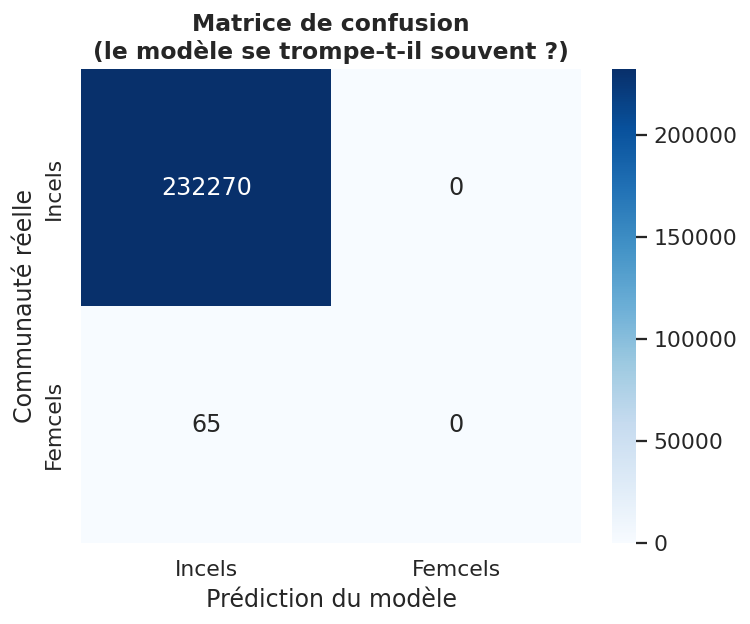

In [ ]:

# 3.3 — MATRICE DE CONFUSION

cm = confusion_matrix(y_test, y_pred, labels=['incels', 'femcels'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Incels', 'Femcels'],
            yticklabels=['Incels', 'Femcels'])
ax.set_xlabel('Prédiction du modèle')
ax.set_ylabel('Communauté réelle')
ax.set_title('Matrice de confusion\n(le modèle se trompe-t-il souvent ?)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion.png', bbox_inches='tight')
plt.show()

La matrice de confusion permet de visualiser les prédictions correctes et les erreurs du modèle. Les lignes correspondent aux communautés réelles, et les colonnes aux communautés prédites par le classifieur.

Ici, le modèle prédit presque systématiquement la classe incel : tous les posts incels sont correctement classés, mais les posts femcels sont eux aussi prédits comme incels. Cela montre surtout l’effet du fort déséquilibre des données : le modèle apprend principalement à reconnaître la classe majoritaire.

---
## Section 4 — Paysage textuel : Vocabulaire partagé vs distinctif

### 4.1 — Bag-of-Words et TF-IDF

Pour comparer les deux communautés, nous transformons les textes en représentations numériques à l’aide de deux méthodes: CountVectorizer et TfidfVectorizer.

Le modèle Bag-of-Words (CountVectorizer) compte simplement combien de fois chaque mot apparaît dans les posts. Cela permet d’identifier les termes les plus fréquents dans chaque communauté.

Le TF-IDF donne plus d’importance aux mots fréquents dans une communauté mais rares dans l’ensemble du corpus. Cette méthode permet donc de repérer les termes les plus caractéristiques et distinctifs des incels et des femcels.

In [ ]:

# 4.1 — BOW + TF-IDF (vocabulaire partagé)


all_texts = pd.concat([corpus_incels, corpus_femcels])

# Bag-of-Words
bow_vec = CountVectorizer(max_df=0.95, min_df=5, max_features=1000, stop_words='english')
bow_matrix = bow_vec.fit_transform(all_texts)
print(f'Matrice BoW : {bow_matrix.shape}')

# TF-IDF
tfidf_vec = TfidfVectorizer(max_df=0.95, min_df=5, max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform(all_texts)
tfidf_features = tfidf_vec.get_feature_names_out()
print(f'Matrice TF-IDF : {tfidf_matrix.shape}')

n_incels = len(corpus_incels)
tfidf_incels  = tfidf_matrix[:n_incels]
tfidf_femcels = tfidf_matrix[n_incels:]

Matrice BoW : (929337, 1000)
Matrice TF-IDF : (929337, 1000)


### 4.2 — Top termes TF-IDF par communauté

Les termes à score TF-IDF élevé sont ceux qui sont à la fois fréquents dans une communauté et rares dans l'autre — ils définissent l'identité lexicale du groupe.

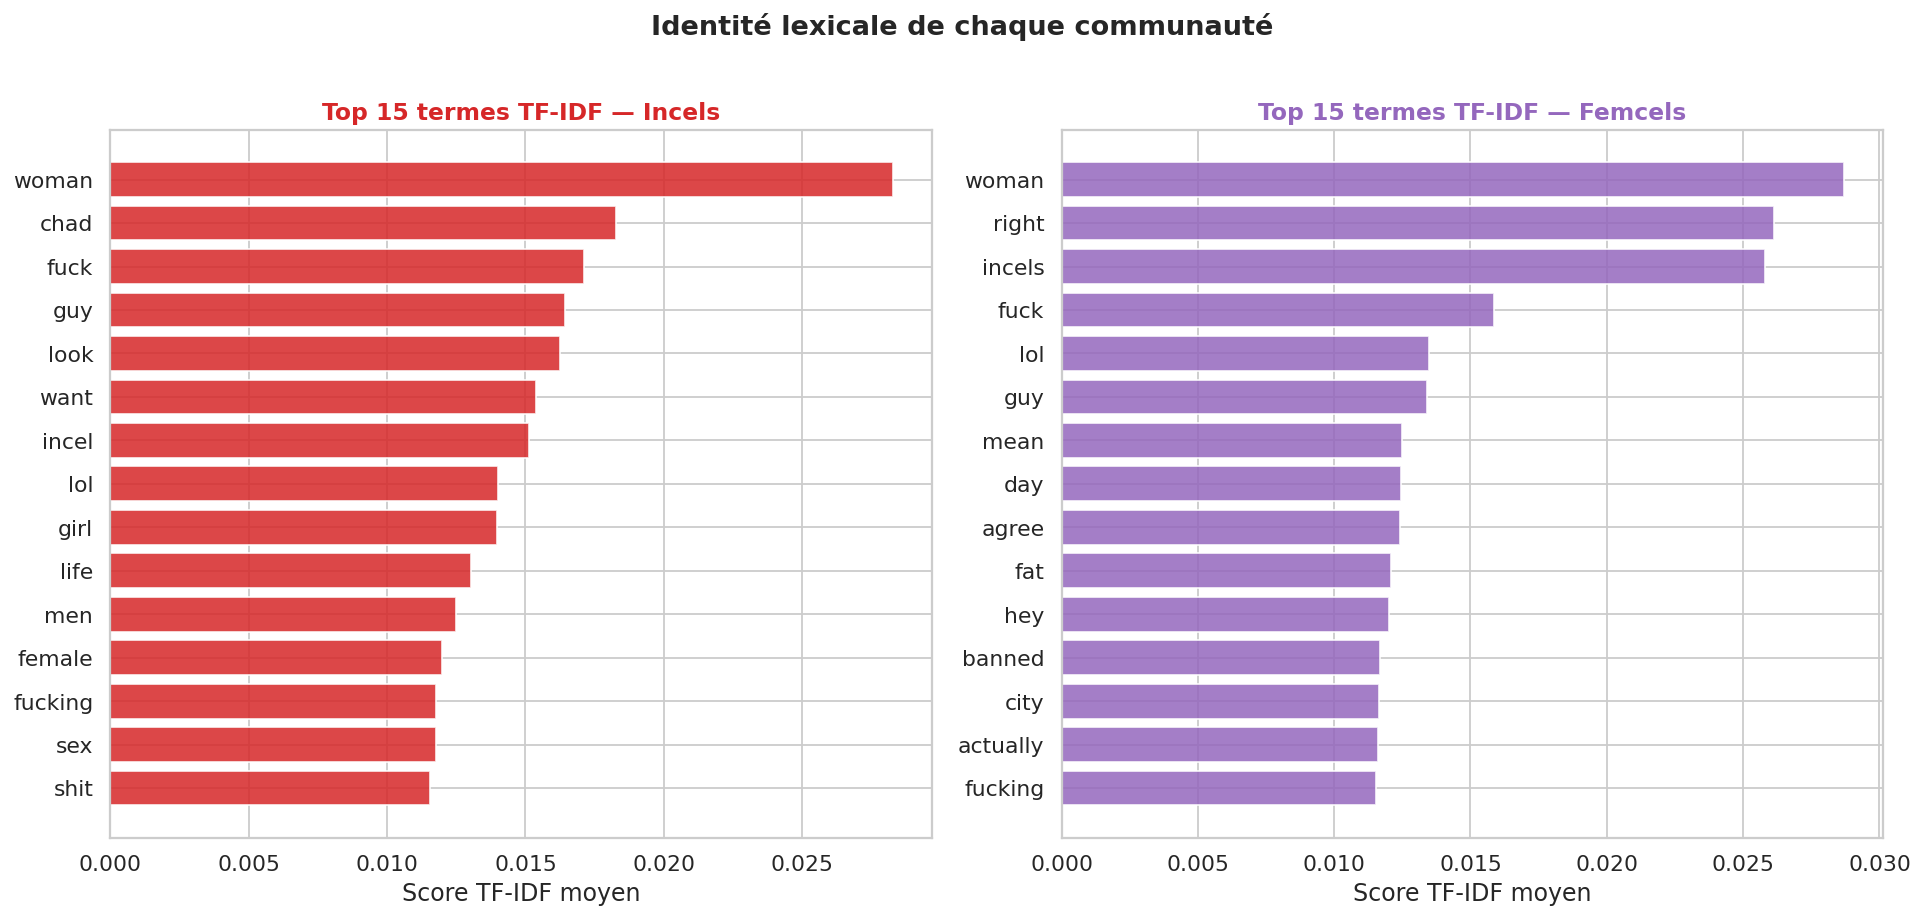

In [ ]:
# ============================================================
# 4.2 — TOP TERMES TF-IDF (barres miroir)
# ============================================================

mean_i = np.asarray(tfidf_incels.mean(axis=0)).flatten()
mean_f = np.asarray(tfidf_femcels.mean(axis=0)).flatten()

N = 15
top_i_idx = mean_i.argsort()[-N:][::-1]
top_f_idx = mean_f.argsort()[-N:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, (name, mean_vals, top_idx) in zip(axes, [
    ('incels', mean_i, top_i_idx), ('femcels', mean_f, top_f_idx)
]):
    words  = tfidf_features[top_idx]
    scores = mean_vals[top_idx]
    ax.barh(words[::-1], scores[::-1], color=PALETTE[name], alpha=0.85, edgecolor='white')
    ax.set_title(f'Top {N} termes TF-IDF — {name.capitalize()}',
                 fontsize=13, fontweight='bold', color=PALETTE[name])
    ax.set_xlabel('Score TF-IDF moyen')

fig.suptitle('Identité lexicale de chaque communauté', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_tfidf_top.png', bbox_inches='tight')
plt.show()

Le TF-IDF met en évidence les mots les plus caractéristiques de chaque communauté. On observe d’abord un vocabulaire partagé autour du genre et des relations (woman, guy, look, sex), ce qui montre que les deux groupes discutent de problématiques similaires.

Mais certains termes deviennent plus spécifiques selon la communauté : chez les incels, des mots comme chad ou incel occupent une place centrale, tandis que chez les femcels apparaissent davantage des termes liés à l’interaction quotidienne et au vécu personnel comme right, agree ou hey. Cela suggère des styles discursifs différents malgré un thème commun.

### 4.3 — Chevauchement du vocabulaire

Quelle proportion de mots est partagée ? Si le chevauchement est faible, les communautés vivent dans des univers linguistiques séparés.

Vocabulaire incels uniquement : 111 mots (27%)
Vocabulaire partagé           : 157 mots (38%)
Vocabulaire femcels uniquement: 146 mots (35%)


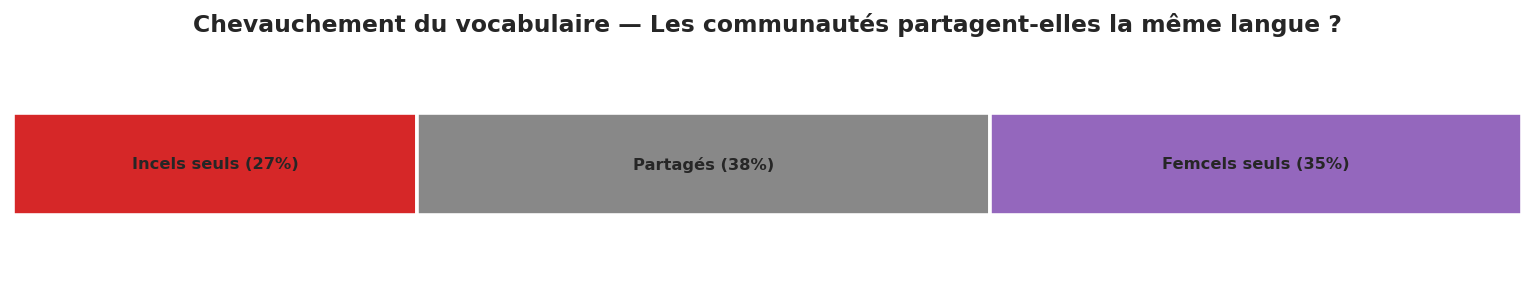

In [ ]:
# 4.3 — CHEVAUCHEMENT DU VOCABULAIRE


# Mots significatifs (TF-IDF > seuil)
threshold = 0.002
vocab_i = set(tfidf_features[mean_i > threshold])
vocab_f = set(tfidf_features[mean_f > threshold])
shared  = vocab_i & vocab_f
only_i  = vocab_i - vocab_f
only_f  = vocab_f - vocab_i

total = len(only_i) + len(shared) + len(only_f)
print(f"Vocabulaire incels uniquement : {len(only_i)} mots ({len(only_i)/total*100:.0f}%)")
print(f"Vocabulaire partagé           : {len(shared)} mots ({len(shared)/total*100:.0f}%)")
print(f"Vocabulaire femcels uniquement: {len(only_f)} mots ({len(only_f)/total*100:.0f}%)")

# Stacked bar visualization
fig, ax = plt.subplots(figsize=(12, 2.5))
pcts = [len(only_i)/total*100, len(shared)/total*100, len(only_f)/total*100]
colors = [PALETTE['incels'], '#888888', PALETTE['femcels']]
labels = [f'Incels seuls ({pcts[0]:.0f}%)', f'Partagés ({pcts[1]:.0f}%)', f'Femcels seuls ({pcts[2]:.0f}%)']
left = 0
for pct, color, label in zip(pcts, colors, labels):
    ax.barh(0, pct, left=left, color=color, height=0.5, edgecolor='white', linewidth=2)
    ax.text(left + pct/2, 0, label, ha='center', va='center', fontsize=9, fontweight='bold')
    left += pct
ax.set_xlim(0, 100)
ax.set_ylim(-0.6, 0.6)
ax.axis('off')
ax.set_title('Chevauchement du vocabulaire — Les communautés partagent-elles la même langue ?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_overlap.png', bbox_inches='tight')
plt.show()

Le graphique montre qu’une partie importante du vocabulaire est effectivement partagée entre les deux communautés (38 %), ce qui confirme l’existence d’un univers thématique commun autour des relations de genre et de la solitude. Cependant, plus de la moitié des termes restent spécifiques à une seule communauté, ce qui indique que les incels et les femcels construisent malgré tout des identités discursives distinctes.

### 4.4 — Fréquences comparées (Top-N)

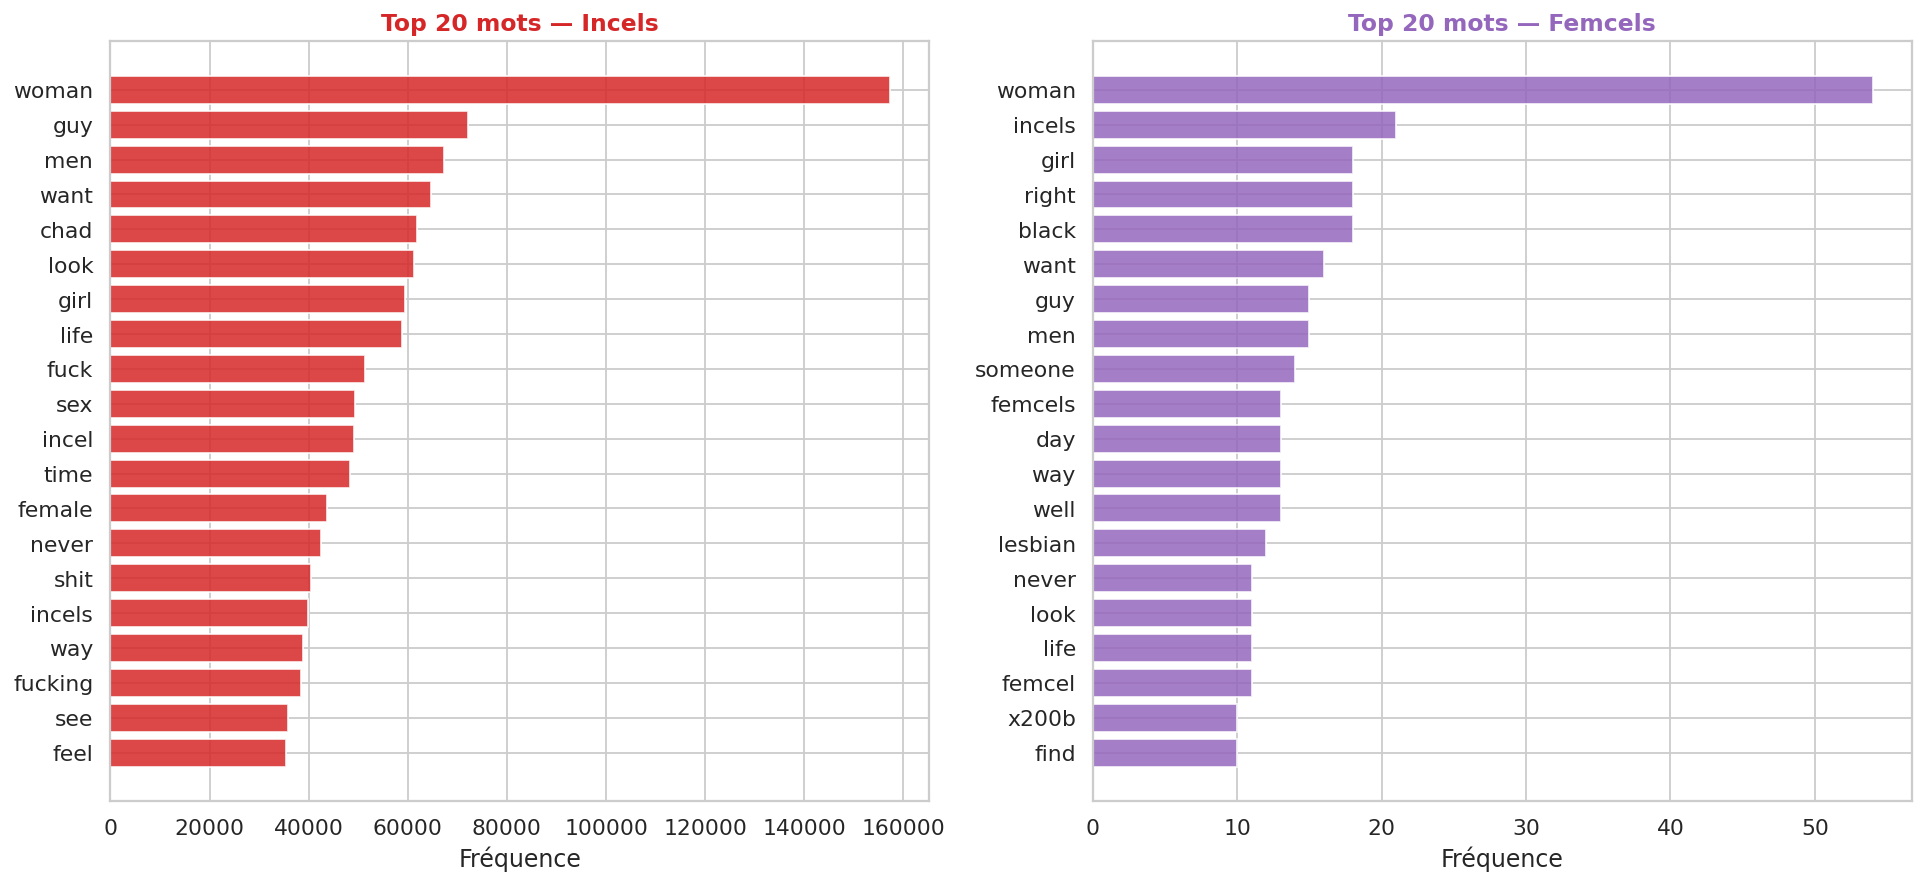

In [ ]:
# ============================================================
# 4.4 — FRÉQUENCES TOP-N
# ============================================================

freq_i = Counter(' '.join(corpus_incels).split())
freq_f = Counter(' '.join(corpus_femcels).split())

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (name, freq) in zip(axes, [('incels', freq_i), ('femcels', freq_f)]):
    words, counts = zip(*freq.most_common(N_FREQ_WORDS))
    ax.barh(words[::-1], counts[::-1], color=PALETTE[name], alpha=0.85, edgecolor='white')
    ax.set_title(f'Top {N_FREQ_WORDS} mots — {name.capitalize()}',
                 fontsize=13, fontweight='bold', color=PALETTE[name])
    ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.savefig('fig_top_words.png', bbox_inches='tight')
plt.show()

Les résultats montrent que les deux communautés partagent certains termes centraux liés au genre et aux relations sociales, notamment *woman*, *man*, *guy*, *girl*

Cependant, plusieurs différences lexicales apparaissent.

Le corpus incel contient davantage de termes associés à la frustration relationnelle et à la culture spécifique du mouvement, comme *chad*, *sex* ou *incel*. Le vocabulaire semble davantage centré sur les rapports hommes-femmes et les hiérarchies de désir.

Chez les femcels, certains termes renvoient davantage à l’identité communautaire et aux interactions sociales, avec des mots comme *femcels*, *someone* ou *lesbian*.

On observe également un déséquilibre important entre les corpus : les fréquences absolues sont beaucoup plus élevées chez les incels en raison d’un volume de données nettement supérieur.

---
## Section 5 — Test de H2 : Asymétrie émotionnelle

VADER décompose le sentiment en 4 scores : `pos`, `neg`, `neu` et `compound`. En comparant non seulement le compound global mais aussi les composantes `pos` et `neg` séparément, on peut distinguer une communauté dominée par la **colère** (neg élevé mais aussi pos élevé = émotions intenses) d'une communauté dominée par la **résignation** (neg modéré, pos très faible = apathie).

### 5.1 — Distribution du sentiment

In [ ]:
!pip install vaderSentiment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.3 MB/s eta 0:00:00


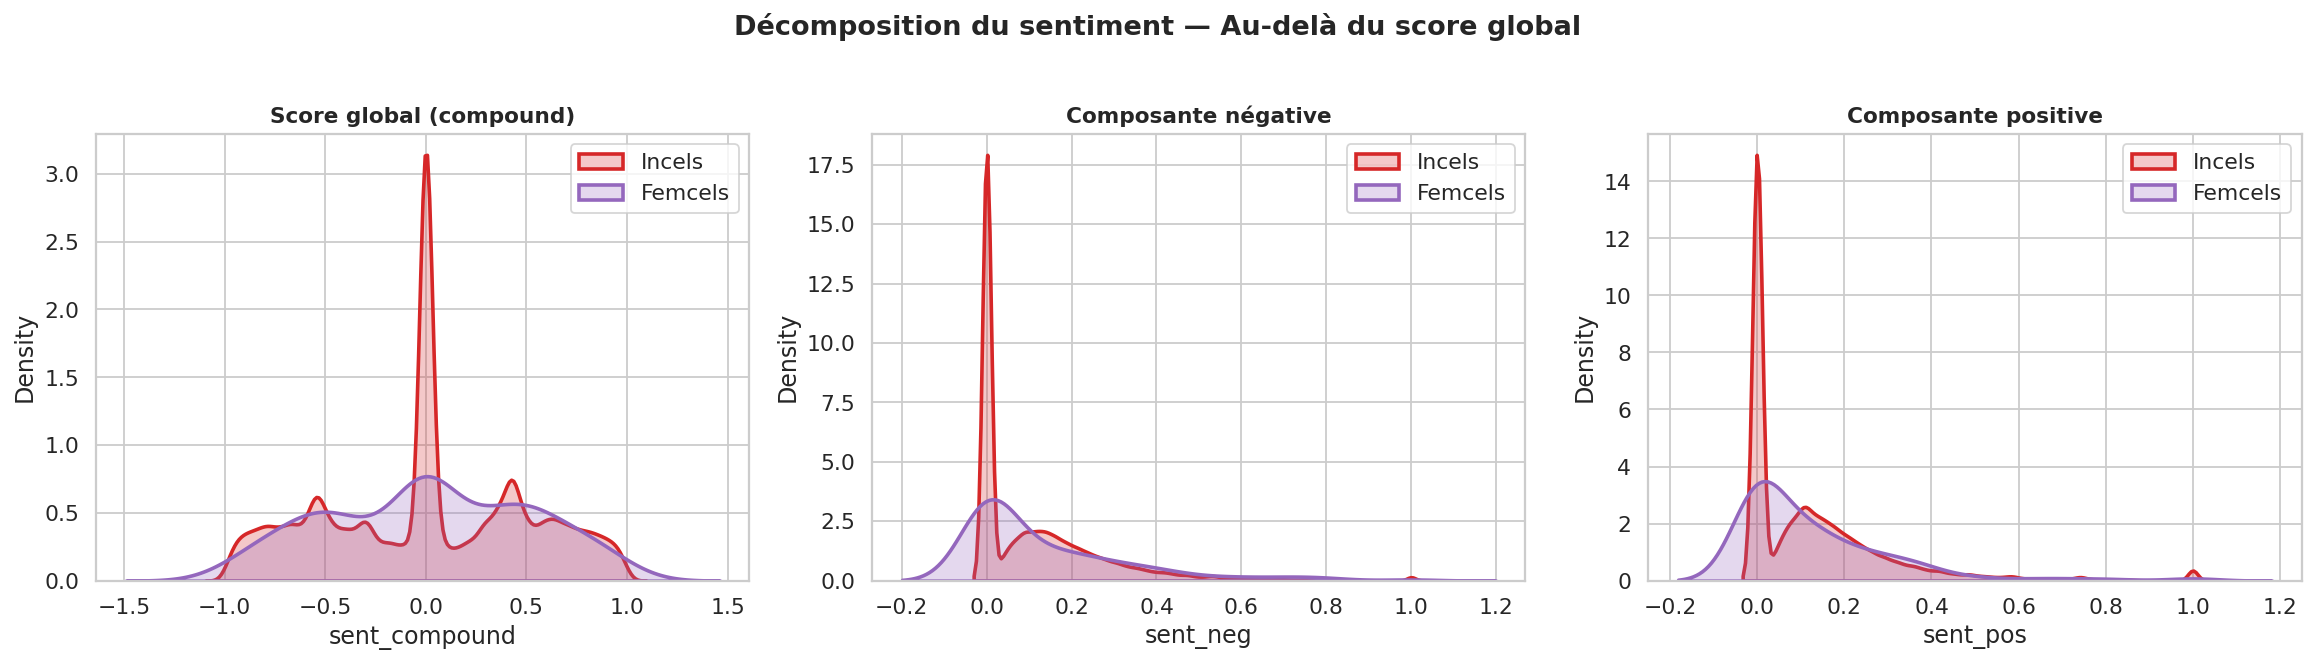

In [ ]:

# 5.1 — ANALYSE DE SENTIMENT (VADER)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

for name, df in datasets.items():
    scores = df['body'].apply(lambda x: analyzer.polarity_scores(str(x)))
    df['sent_compound'] = scores.apply(lambda s: s['compound'])
    df['sent_pos']      = scores.apply(lambda s: s['pos'])
    df['sent_neg']      = scores.apply(lambda s: s['neg'])
    df['sent_neu']      = scores.apply(lambda s: s['neu'])
    df['sent_label'] = df['sent_compound'].apply(
        lambda s: 'POSITIF' if s >= 0.05 else ('NÉGATIF' if s <= -0.05 else 'NEUTRE')
    )

# KDE comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(axes,
    ['sent_compound', 'sent_neg', 'sent_pos'],
    ['Score global (compound)', 'Composante négative', 'Composante positive']):
    for name, df in datasets.items():
        sns.kdeplot(df[col], ax=ax, label=name.capitalize(),
                    color=PALETTE[name], fill=True, alpha=0.25, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()

fig.suptitle('Décomposition du sentiment — Au-delà du score global',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_sentiment_decomposed.png', bbox_inches='tight')
plt.show()

Les distributions montrent que les deux communautés produisent une grande quantité de messages proches de la neutralité, ce qui est fréquent sur Reddit à cause des réponses courtes ou descriptives.

La différence apparaît surtout dans les extrêmes : chez les incels, les courbes sont plus étalées, avec davantage de messages très négatifs mais aussi très positifs. Le discours semble donc émotionnellement plus polarisé et plus intense. Chez les femcels, les distributions restent plus resserrées autour du centre, ce qui suggère une expression émotionnelle plus homogène et moins extrême.

### 5.2 — La négativité alimente-t-elle la participation ?

Question de recherche : les auteurs les plus prolifiques sont-ils aussi les plus négatifs ? Si oui, la communauté récompense structurellement le discours toxique.

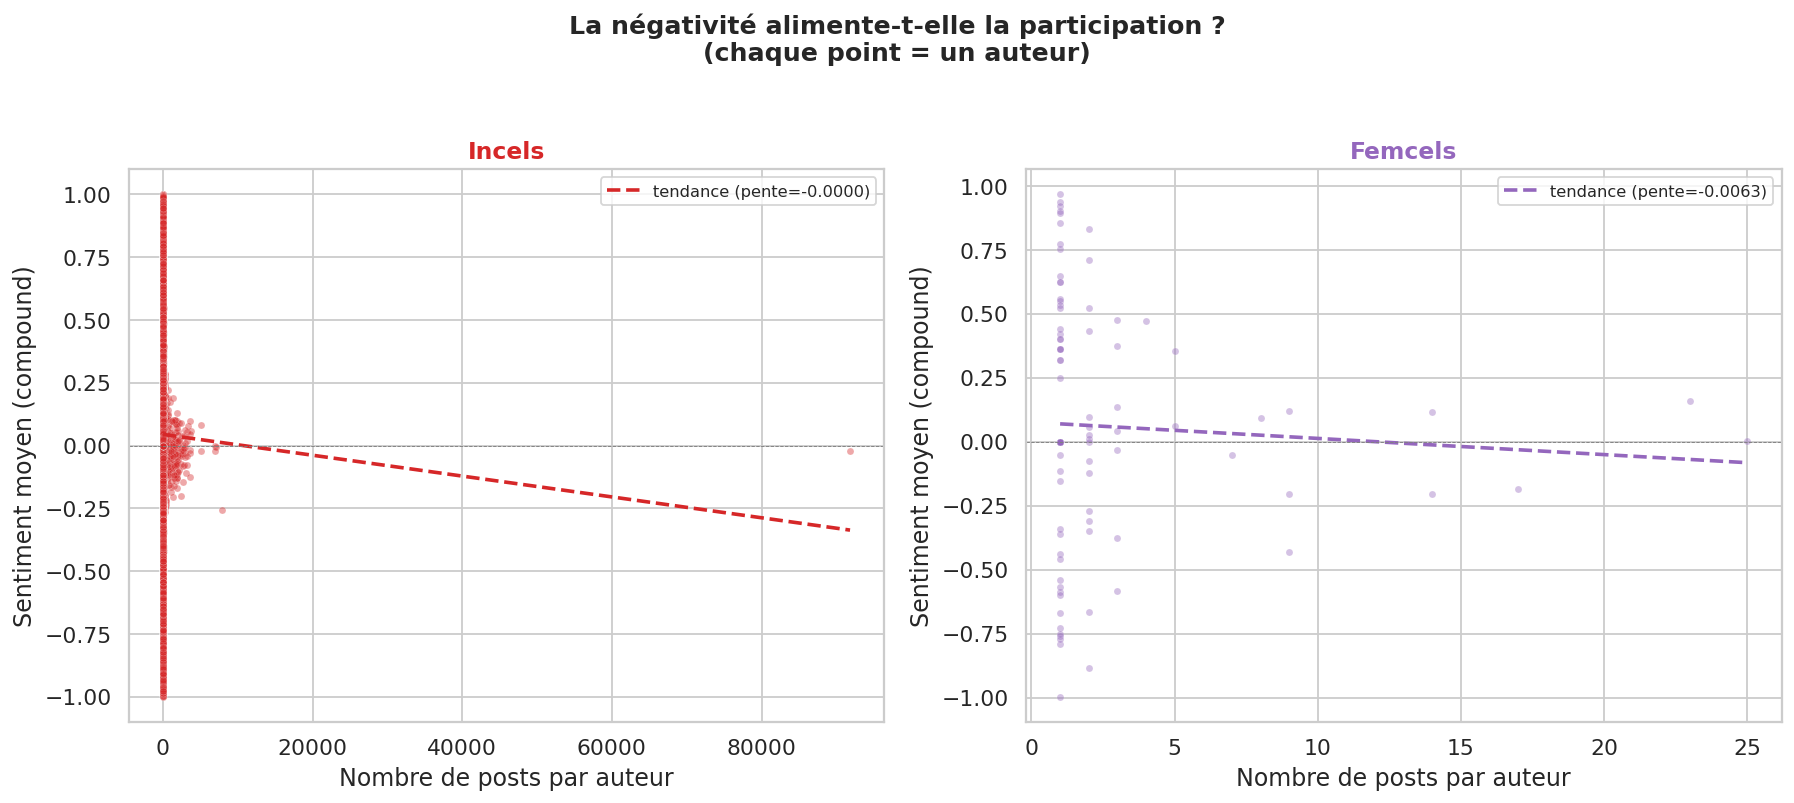

In [ ]:

# 5.2 — NEGATIVITÉ × PROLIFICITÉ

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, df) in zip(axes, datasets.items()):
    author_stats = df.groupby('author').agg(
        n_posts=('body', 'count'),
        mean_sentiment=('sent_compound', 'mean')
    ).reset_index()

    ax.scatter(author_stats['n_posts'], author_stats['mean_sentiment'],
               s=15, alpha=0.4, color=PALETTE[name], edgecolors='white', linewidth=0.2)

    # Regression line
    if len(author_stats) > 10:
        z = np.polyfit(author_stats['n_posts'], author_stats['mean_sentiment'], 1)
        x_line = np.linspace(1, author_stats['n_posts'].max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), '--', color=PALETTE[name],
                linewidth=2, label=f'tendance (pente={z[0]:.4f})')
        ax.legend(fontsize=9)

    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Nombre de posts par auteur')
    ax.set_ylabel('Sentiment moyen (compound)')
    ax.set_title(f'{name.capitalize()}', fontsize=13, fontweight='bold', color=PALETTE[name])

fig.suptitle('La négativité alimente-t-elle la participation ?\n(chaque point = un auteur)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig_negativity_engagement.png', bbox_inches='tight')
plt.show()

Chaque point représente ici un auteur : l’axe horizontal indique son nombre de posts, et l’axe vertical le niveau moyen de sentiment de ses messages.

On observe dans les deux communautés une corrélation très faible entre activité et négativité : publier davantage ne signifie pas nécessairement produire un contenu plus négatif. Cependant, chez les incels, certains utilisateurs publient une quantité extrêmement élevée de messages, ce qui confirme l’existence d’un noyau hyperactif structurant fortement la communauté.

### 5.3 — Répartition des sentiments

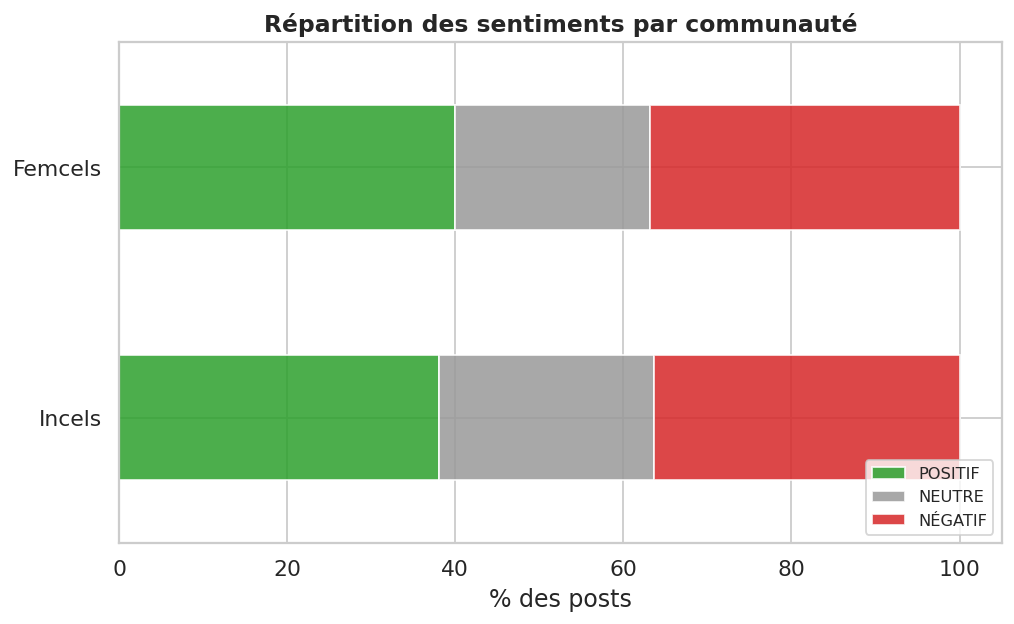

In [ ]:

# 5.3 — RÉPARTITION DES SENTIMENTS


fig, ax = plt.subplots(figsize=(8, 5))
sent_data = {}
for name, df in datasets.items():
    counts = df['sent_label'].value_counts(normalize=True) * 100
    sent_data[name.capitalize()] = counts

sent_df = pd.DataFrame(sent_data).T.reindex(columns=['POSITIF', 'NEUTRE', 'NÉGATIF'])
sent_df.plot(kind='barh', stacked=True, ax=ax,
             color=['#2ca02c', '#999999', '#d62728'], edgecolor='white', alpha=0.85)
ax.set_xlabel('% des posts')
ax.set_title('Répartition des sentiments par communauté', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_sentiment_bars.png', bbox_inches='tight')
plt.show()

La répartition générale des sentiments reste relativement proche dans les deux communautés : une grande partie des posts est classée comme positive ou neutre, tandis que les contenus négatifs représentent environ un tiers des messages.

Cependant, les incels présentent une proportion légèrement plus élevée de posts négatifs, ce qui va dans le sens d’un discours plus conflictuel et émotionnellement polarisé. Les différences restent néanmoins modérées et doivent être interprétées avec prudence

---
## Section 6 — Test de H3 : Chambre d'écho

Nous utilisons ici deux indicateurs complémentaires :

La concentration du contenu : si une très petite partie des auteurs produit une grande proportion des posts, cela signifie que la parole est fortement dominée par quelques utilisateurs hyperactifs.
La richesse lexicale : nous observons l’évolution du ratio type-token (nombre de mots uniques rapporté au nombre total de mots). Si ce ratio diminue chez les auteurs les plus actifs, cela suggère un vocabulaire plus répétitif et donc un possible effet de chambre d’écho.

### 6.1 — Concentration du contenu

In [ ]:

# 6.1 — TABLEAU DE CONCENTRATION

rows = []
for name, df in datasets.items():
    total = len(df)
    unique = df['author'].nunique()
    counts = df['author'].value_counts()
    def top_share(pct):
        n = max(1, int(np.ceil(unique * pct)))
        return round(counts.iloc[:n].sum() / total * 100, 1)
    rows.append({
        'Communauté': name.capitalize(), 'Total posts': total,
        'Auteurs uniques': unique, 'Posts/auteur': round(total/unique, 1),
        'Top 1%': top_share(0.01), 'Top 5%': top_share(0.05), 'Top 10%': top_share(0.10),
    })
stats_df = pd.DataFrame(rows).set_index('Communauté')
stats_df

,Total posts,Auteurs uniques,Posts/auteur,Top 1%,Top 5%,Top 10%
Communauté,,,,,,
Incels,929079,37597,24.7,57.0,80.4,87.5
Femcels,258,92,2.8,9.7,36.0,52.3


On observe un contraste très fort entre les deux communautés. Les incels disposent d’un volume de contenu massif et d’une activité extrêmement concentrée : le top 1 % des auteurs produit à lui seul 57 % des posts, et le top 10 % près de 88 %. Cela suggère une communauté fortement structurée autour d’un noyau hyperactif.

Chez les femcels, la production reste beaucoup plus dispersée et moins centralisée.

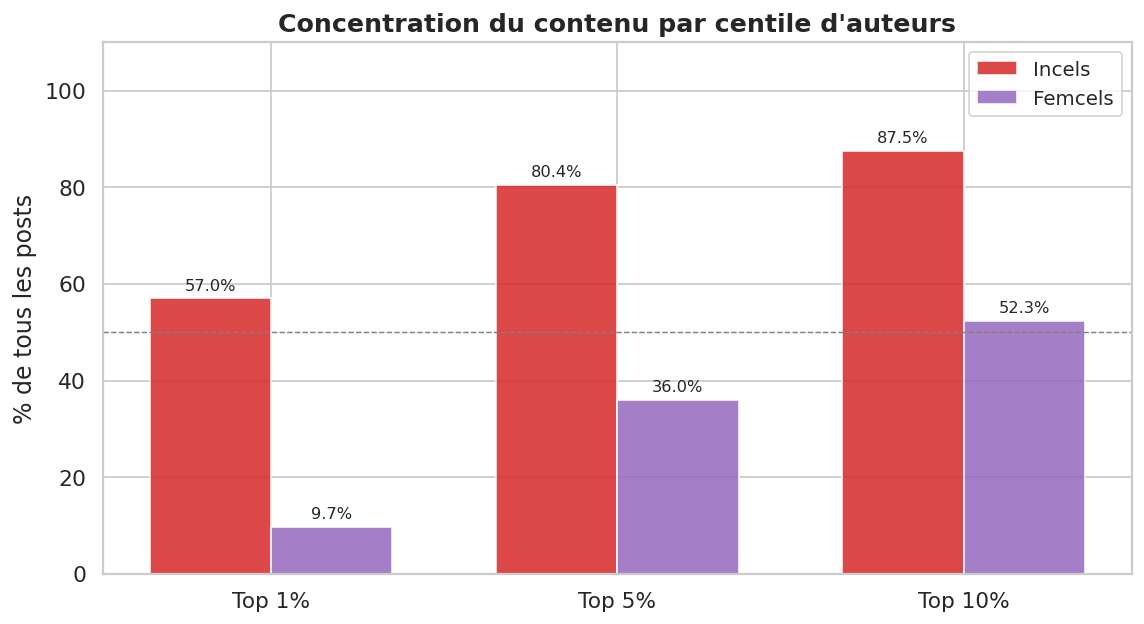

In [ ]:

# 6.2 — GRAPHIQUE DE CONCENTRATION

share_cols = ['Top 1%', 'Top 5%', 'Top 10%']
x = np.arange(len(share_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, (community, row) in enumerate(stats_df.iterrows()):
    name = community.lower()
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, row[share_cols].values, width,
                  label=community, color=PALETTE[name], alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(share_cols, fontsize=12)
ax.set_ylabel('% de tous les posts')
ax.set_ylim(0, 110)
ax.set_title('Concentration du contenu par centile d\'auteurs', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(50, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('fig_concentration.png', bbox_inches='tight')
plt.show()

### 6.3 — Richesse lexicale par « couche » d'auteurs

On découpe les auteurs en 3 groupes : top 10% (les plus actifs), les 10-50%, et les 50-100% (les plus occasionnels). On calcule le ratio type-token (TTR) de chaque couche. Si le TTR est plus faible chez les auteurs les plus actifs, ils recyclent davantage le même vocabulaire — signe d'une chambre d'écho linguistique.

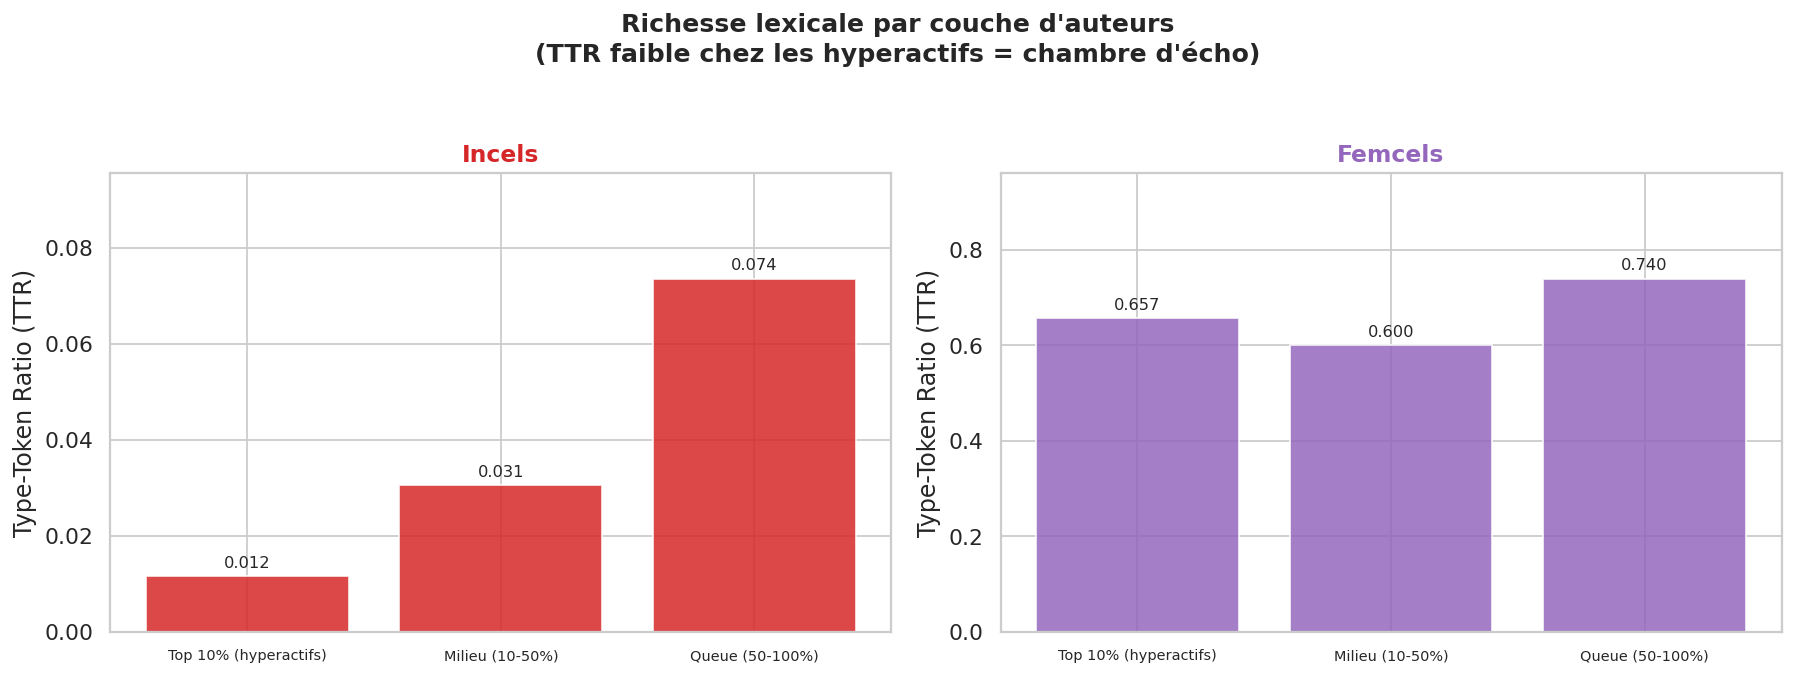

In [ ]:

# 6.3 — RICHESSE LEXICALE PAR COUCHE D'AUTEURS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    counts = df['author'].value_counts()
    n = len(counts)

    # Define tiers
    tiers = {
        'Top 10% (hyperactifs)': counts.index[:max(1, int(n*0.1))],
        'Milieu (10-50%)'      : counts.index[int(n*0.1):int(n*0.5)],
        'Queue (50-100%)'      : counts.index[int(n*0.5):],
    }

    ttr_vals = []
    tier_labels = []
    for tier_name, authors in tiers.items():
        posts = df[df['author'].isin(authors)]['clean']
        all_tokens = ' '.join(posts).split()
        if len(all_tokens) > 0:
            ttr = len(set(all_tokens)) / len(all_tokens)
        else:
            ttr = 0
        ttr_vals.append(ttr)
        tier_labels.append(tier_name)

    bars = ax.bar(tier_labels, ttr_vals, color=PALETTE[name], alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_ylabel('Type-Token Ratio (TTR)')
    ax.set_title(f'{name.capitalize()}', fontsize=13, fontweight='bold', color=PALETTE[name])
    ax.set_ylim(0, max(ttr_vals) * 1.3 if ttr_vals else 1)
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Richesse lexicale par couche d\'auteurs\n(TTR faible chez les hyperactifs = chambre d\'écho)',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('fig_ttr_tiers.png', bbox_inches='tight')
plt.show()

Chez les incels, les auteurs les plus actifs utilisent un vocabulaire beaucoup plus répétitif : le TTR du top 10 % n’est que de 0.012, contre 0.074 chez les auteurs les moins actifs. Cela suggère un fort effet de chambre d’écho, où un petit noyau répète continuellement les mêmes thèmes et formulations.

Chez les femcels, la richesse lexicale reste plus stable entre les groupes d’auteurs. Mais encore une fois, le faible volume de données impose de rester prudent dans l’interprétation.

### 6.4 — Distribution log-log (loi de puissance)

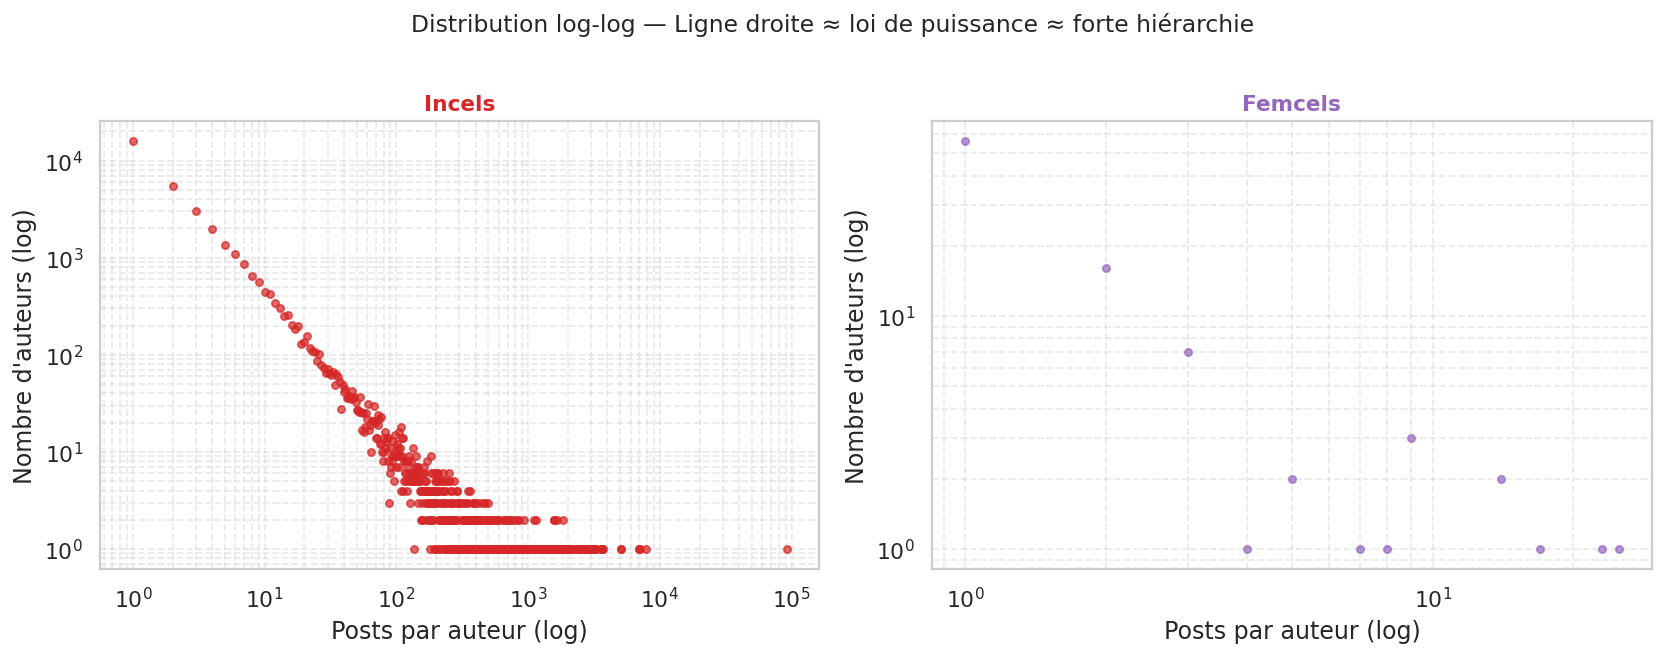

In [ ]:

# 6.4 — LOG-LOG

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, df) in zip(axes, datasets.items()):
    counts = df['author'].value_counts()
    freq_dist = counts.value_counts().sort_index()
    ax.loglog(freq_dist.index, freq_dist.values, 'o', markersize=4,
              color=PALETTE[name], alpha=0.7)
    ax.set_title(f'{name.capitalize()}', fontsize=12, fontweight='bold', color=PALETTE[name])
    ax.set_xlabel('Posts par auteur (log)')
    ax.set_ylabel('Nombre d\'auteurs (log)')
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
fig.suptitle('Distribution log-log — Ligne droite ≈ loi de puissance ≈ forte hiérarchie',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_loglog.png', bbox_inches='tight')
plt.show()

La distribution suit ici une logique de type power law : une immense majorité des utilisateurs publie très peu, tandis qu’une minorité extrêmement réduite produit une quantité disproportionnée de contenu. Ce phénomène est particulièrement marqué chez les incels, où la structure apparaît fortement hiérarchisée et dominée par quelques auteurs hyperactifs.

---
## Section 7 — Cartographie temporelle

### 7.1 — Volume mensuel

L'analyse temporelle permet de répondre à trois questions clés :

- Quand chaque communauté a-t-elle connu sa croissance ? (évolution mensuelle)
- Quels rythmes les utilisateurs suivent-ils ? (carte thermique jour × heure)
- Existe-t-il des pics d'activité corrélés à des événements médiatiques externes ?

Cependant, nous avons choisi de ne pas intégrer cette partie dans le poster final. Le corpus femcel étant très limité, l’analyse temporelle risquait de produire des interprétations fragiles. De plus, il est méthodologiquement difficile d’attribuer un pic d’activité à un événement externe précis sans preuve directe : ces variations peuvent tout autant relever de fluctuations ordinaires de l’activité de la plateforme. Nous avons donc préféré éviter toute surinterprétation des données.

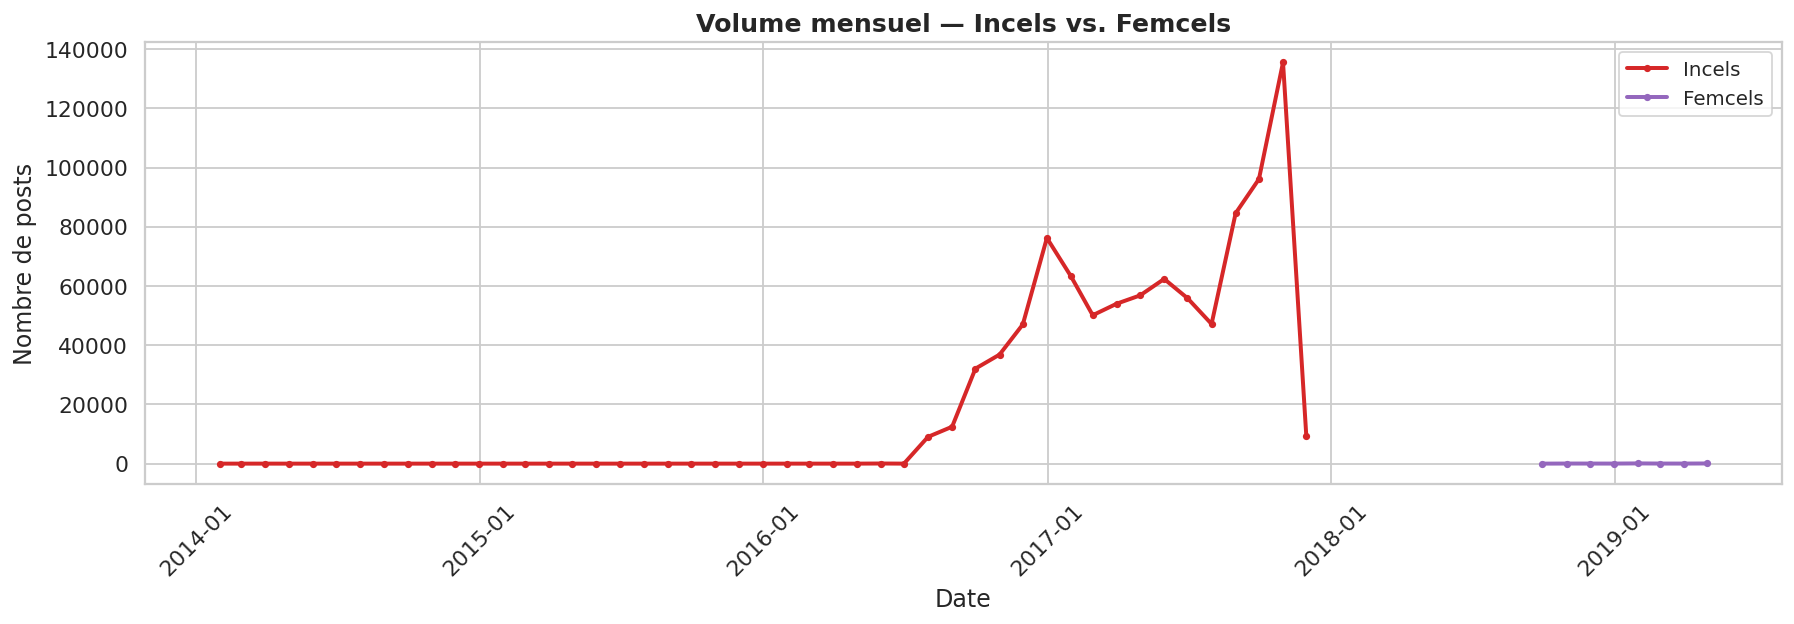

In [ ]:

# 7.1 — VOLUME MENSUEL

fig, ax = plt.subplots(figsize=(14, 5))
for name, df in datasets.items():
    if 'created_utc' not in df.columns: continue
    monthly = df.set_index('created_utc').resample('ME').size()
    ax.plot(monthly.index, monthly.values, label=name.capitalize(),
            color=PALETTE[name], linewidth=2.2, marker='o', markersize=3)
ax.set_title('Volume mensuel — Incels vs. Femcels', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Nombre de posts')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_monthly.png', bbox_inches='tight')
plt.show()

### 7.2 — Contagion émotionnelle : le sentiment évolue-t-il avec le volume ?

Si les pics d'activité coïncident avec des baisses du sentiment moyen, cela suggère que les événements externes provoquent des vagues de négativité collective.

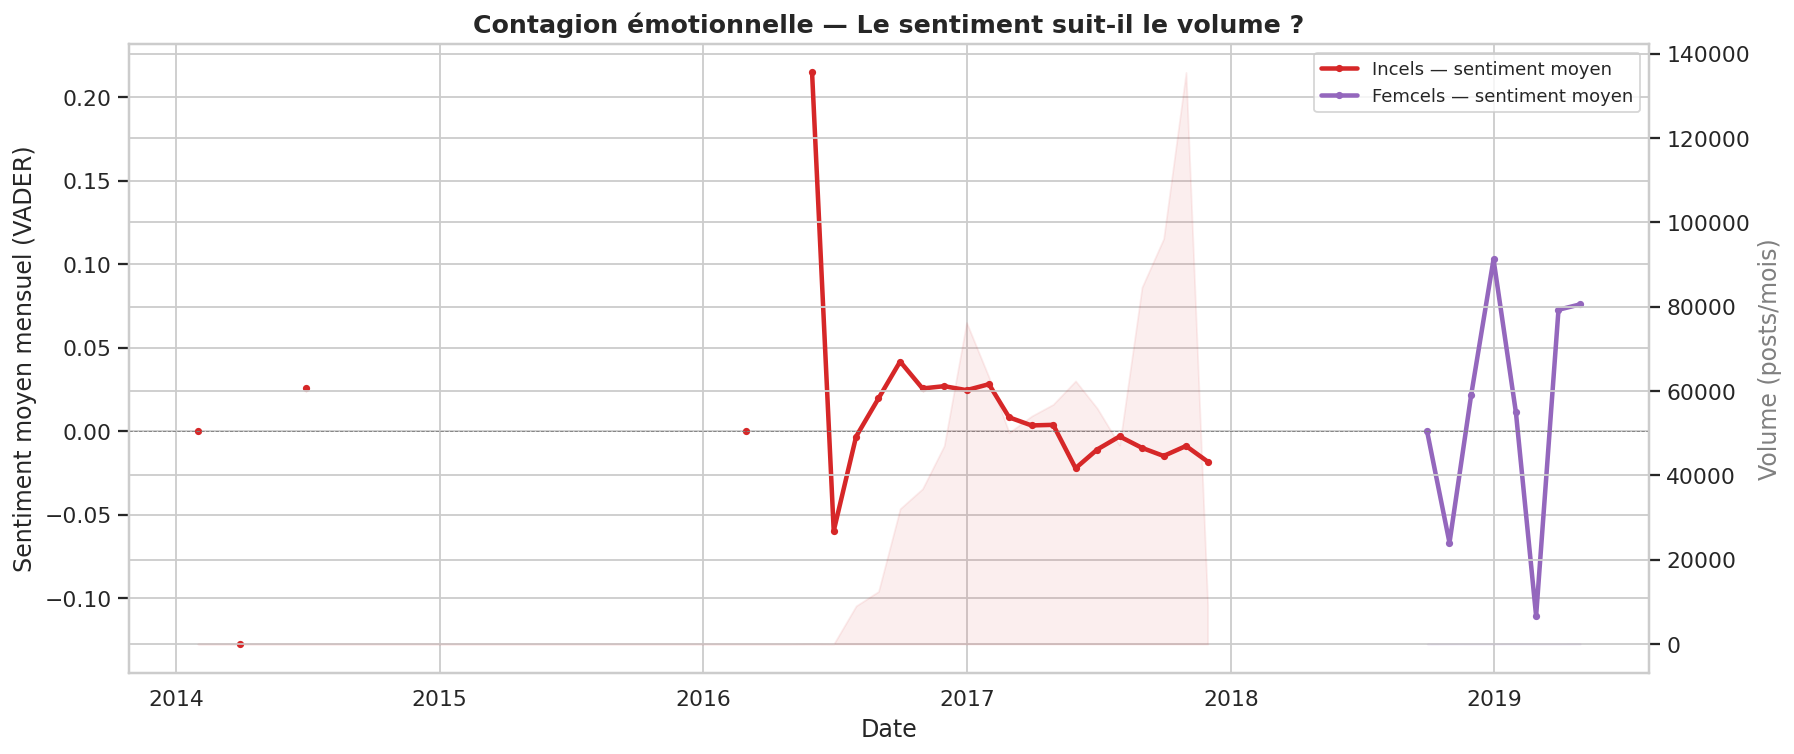

In [ ]:

# 7.2 — SENTIMENT TEMPOREL × VOLUME


fig, ax1 = plt.subplots(figsize=(14, 6))

for name, df in datasets.items():
    if 'created_utc' not in df.columns: continue
    ts = df.set_index('created_utc').sort_index()
    monthly_sent = ts['sent_compound'].resample('ME').mean()
    monthly_vol  = ts['sent_compound'].resample('ME').count()

    ax1.plot(monthly_sent.index, monthly_sent.values, color=PALETTE[name],
             linewidth=2.5, label=f'{name.capitalize()} — sentiment moyen',
             marker='o', markersize=3)

ax1.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax1.set_ylabel('Sentiment moyen mensuel (VADER)')
ax1.set_xlabel('Date')
ax1.set_title('Contagion émotionnelle — Le sentiment suit-il le volume ?',
              fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
for name, df in datasets.items():
    if 'created_utc' not in df.columns: continue
    monthly_vol = df.set_index('created_utc').resample('ME').size()
    ax2.fill_between(monthly_vol.index, monthly_vol.values,
                     color=PALETTE[name], alpha=0.08)

ax2.set_ylabel('Volume (posts/mois)', color='grey')
ax1.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_contagion.png', bbox_inches='tight')
plt.show()

### 7.3 — Heatmap d'activité (jour × heure)

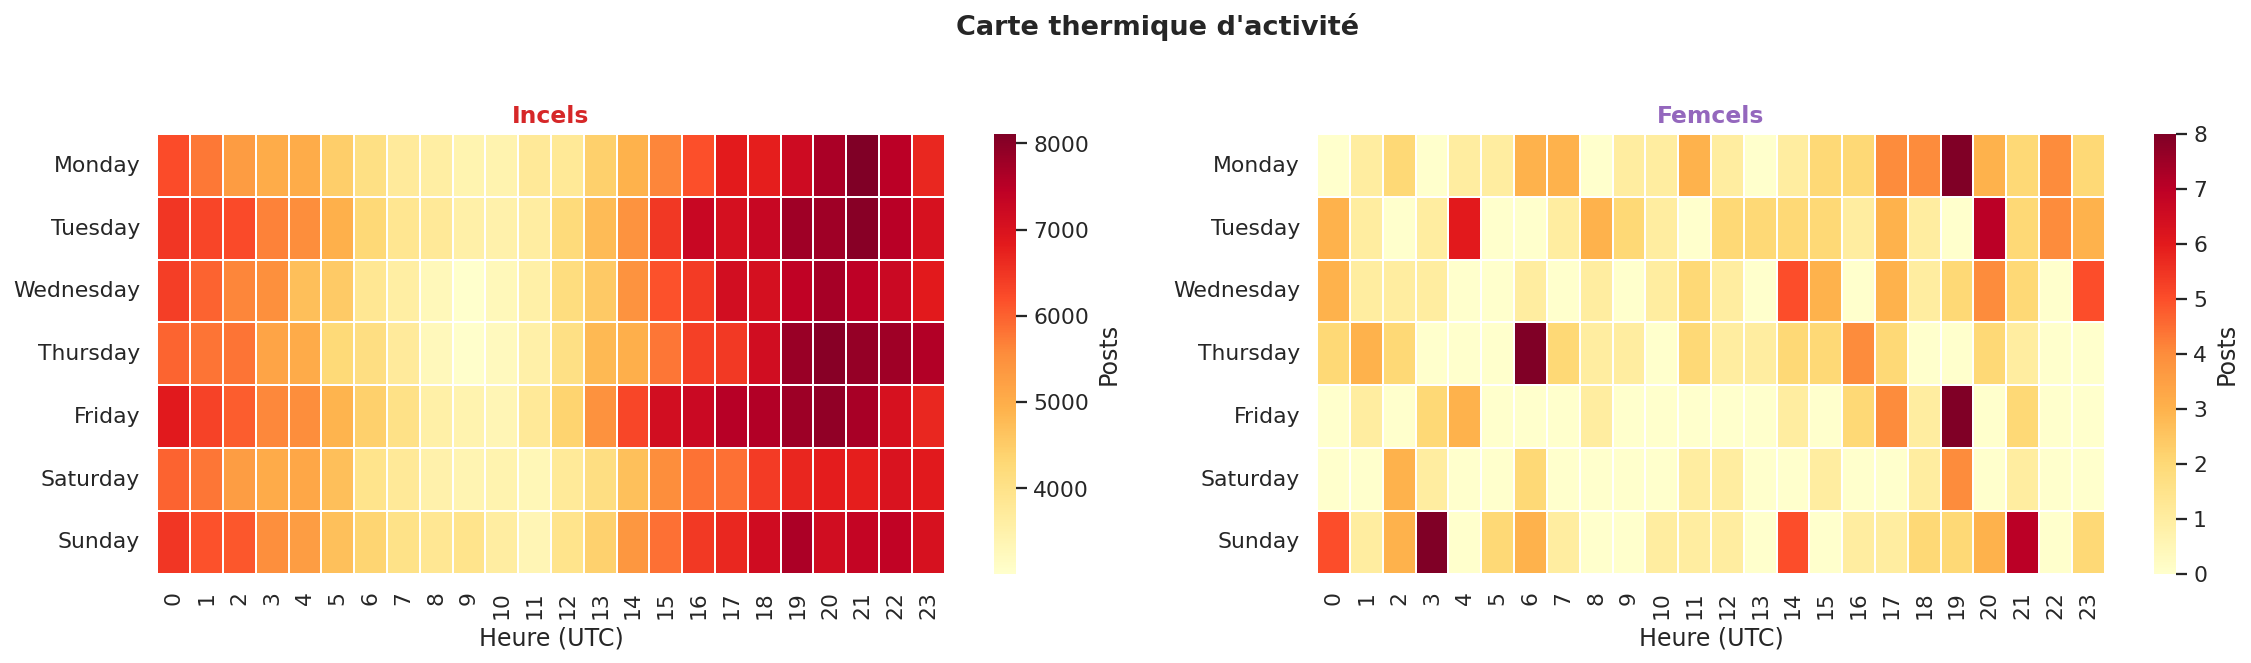

In [ ]:
# 7.3 — HEATMAP

DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, (name, df) in zip(axes, datasets.items()):
    if 'created_utc' not in df.columns: ax.set_visible(False); continue
    tmp = df.copy()
    tmp['hour'] = tmp['created_utc'].dt.hour
    tmp['weekday'] = tmp['created_utc'].dt.day_name()
    pivot = tmp.groupby(['weekday','hour']).size().unstack(fill_value=0).reindex(DAY_ORDER)
    sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.2, ax=ax,
                cbar_kws={'label': 'Posts'})
    ax.set_title(f'{name.capitalize()}', fontsize=13, fontweight='bold', color=PALETTE[name])
    ax.set_xlabel('Heure (UTC)')
    ax.set_ylabel('')
fig.suptitle('Carte thermique d\'activité', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_heatmaps.png', bbox_inches='tight')
plt.show()

### 7.4 — Détection de pics


[incels] Pics (z > 3σ) :
  2017-09-17  32,200 posts  mots-clés=844
  2017-10-22  34,996 posts  mots-clés=993
  2017-10-29  39,864 posts  mots-clés=1042

[femcels] Pics (z > 3σ) :
  2019-01-20  35 posts  mots-clés=0


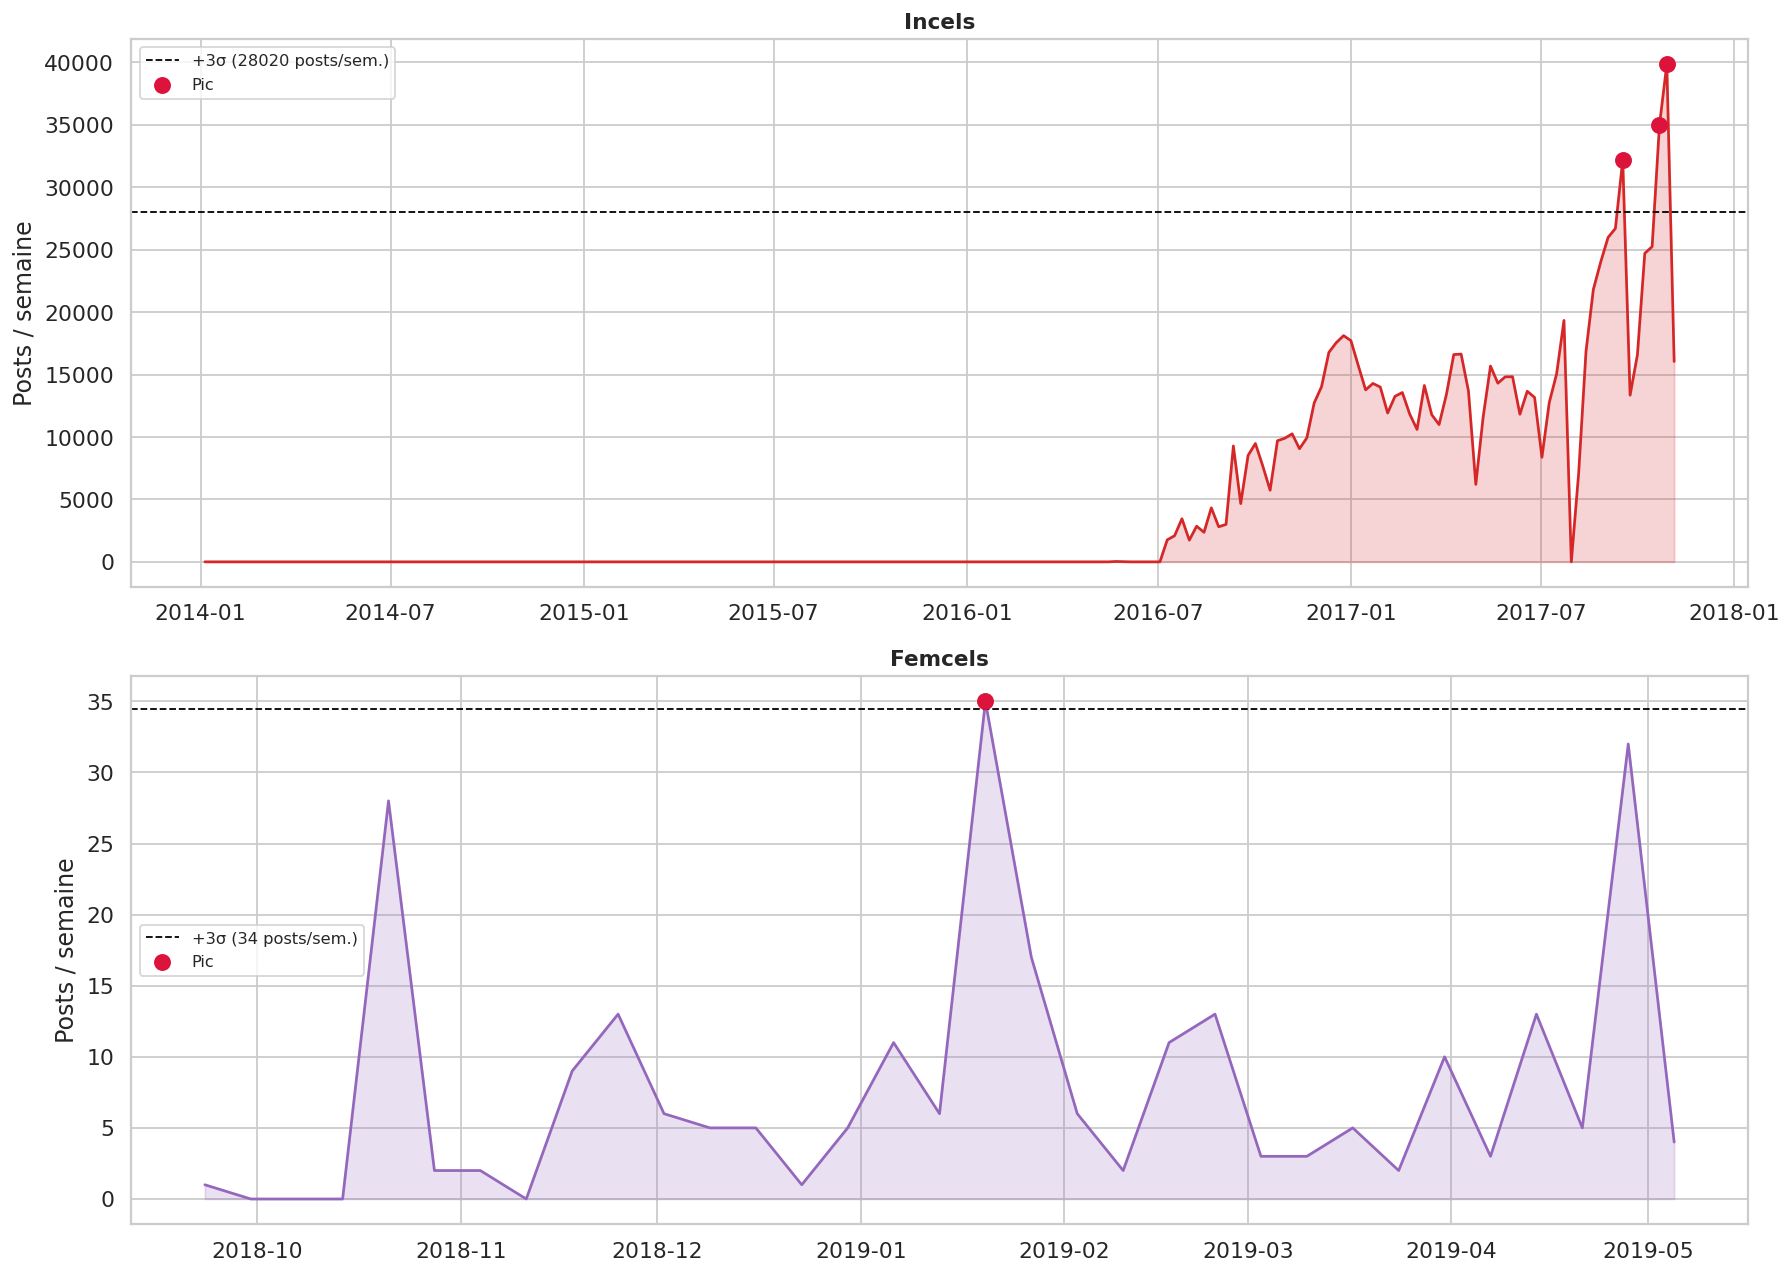

In [ ]:
# 7.4 — SPIKES

EVENT_KEYWORDS = ['adolescence','netflix','series','show','shooting',
                  'manifesto','attack','news','media','viral']

fig, axes = plt.subplots(len(datasets), 1, figsize=(14, 5*len(datasets)), sharex=False)
if len(datasets) == 1: axes = [axes]

for ax, (name, df) in zip(axes, datasets.items()):
    if 'created_utc' not in df.columns: continue
    weekly = df.set_index('created_utc').resample('W').size()
    mu, sigma = weekly.mean(), weekly.std()
    threshold = mu + 3 * sigma
    ax.fill_between(weekly.index, weekly.values, color=PALETTE[name], alpha=0.2)
    ax.plot(weekly.index, weekly.values, color=PALETTE[name], linewidth=1.5)
    ax.axhline(threshold, color='black', linestyle='--', linewidth=1,
               label=f'+3σ ({threshold:.0f} posts/sem.)')
    spike_mask = weekly > threshold
    ax.scatter(weekly.index[spike_mask], weekly.values[spike_mask],
               color='crimson', zorder=5, s=70, label='Pic')
    print(f'\n[{name}] Pics (z > 3σ) :')
    for ts, count in weekly[spike_mask].items():
        week_start = ts - pd.Timedelta(days=7)
        mask_week = (df['created_utc'] >= week_start) & (df['created_utc'] <= ts)
        sample = df.loc[mask_week, 'body'].str.lower()
        hits = sample.apply(lambda t: any(kw in t for kw in EVENT_KEYWORDS)).sum()
        print(f'  {ts.date()}  {int(count):,} posts  mots-clés={hits}')
    ax.set_title(f'{name.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Posts / semaine')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_spikes.png', bbox_inches='tight')
plt.show()